In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/prash/Desktop/Data Analytics/Project 2/Dataset/raw_dataset.csv")

df.head()
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                24042 non-null  str    
 1   machine_id               24042 non-null  int64  
 2   machine_type             24042 non-null  str    
 3   vibration_rms            23042 non-null  float64
 4   temperature_motor        23208 non-null  float64
 5   current_phase_avg        23311 non-null  float64
 6   pressure_level           23118 non-null  float64
 7   rpm                      23509 non-null  float64
 8   operating_mode           24042 non-null  str    
 9   hours_since_maintenance  24042 non-null  float64
 10  ambient_temp             24042 non-null  float64
 11  rul_hours                24042 non-null  float64
 12  failure_within_24h       24042 non-null  int64  
 13  failure_type             24042 non-null  str    
 14  estimated_repair_cost    24042 no

timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_within_24h            0
failure_type                  0
estimated_repair_cost         0
dtype: int64

In [2]:
df.shape
df.columns
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [3]:
df.shape
df.isna().sum()
df.dtypes

timestamp                      str
machine_id                   int64
machine_type                   str
vibration_rms              float64
temperature_motor          float64
current_phase_avg          float64
pressure_level             float64
rpm                        float64
operating_mode                 str
hours_since_maintenance    float64
ambient_temp               float64
rul_hours                  float64
failure_within_24h           int64
failure_type                   str
estimated_repair_cost        int64
dtype: object

In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [5]:
df.to_csv("cleaned_step1_basic_clean.csv", index=False)

In [6]:
df.isna().sum()

timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_within_24h            0
failure_type                  0
estimated_repair_cost         0
dtype: int64

In [7]:
# Sensor columns only
sensor_cols = [
    "vibration_rms",
    "temperature_motor",
    "current_phase_avg",
    "pressure_level",
    "rpm"
]

for col in sensor_cols:
    df[col] = df.groupby("machine_id")[col].transform(
        lambda x: x.fillna(x.median())
    )

In [8]:
df.isna().sum()

timestamp                  0
machine_id                 0
machine_type               0
vibration_rms              0
temperature_motor          0
current_phase_avg          0
pressure_level             0
rpm                        0
operating_mode             0
hours_since_maintenance    0
ambient_temp               0
rul_hours                  0
failure_within_24h         0
failure_type               0
estimated_repair_cost      0
dtype: int64

In [10]:
df.to_csv("cleaned_maintenance_data.csv", index=False)

In [11]:
df["failure_within_24h"].mean()

df.groupby("machine_type")["failure_within_24h"].mean()

df.groupby("machine_type")["rul_hours"].mean()

machine_type
CNC            27.417650
Compressor     31.174574
Pump           26.545994
Robotic Arm    26.139300
Name: rul_hours, dtype: float64

In [12]:
df["failure_within_24h"].mean()

df.groupby("machine_type")["failure_within_24h"].mean()

machine_type
CNC            0.140475
Compressor     0.159987
Pump           0.149329
Robotic Arm    0.142429
Name: failure_within_24h, dtype: float64

In [13]:
# Normalize RUL (lower RUL = worse)
df["rul_normalized"] = 1 - (
    (df["rul_hours"] - df["rul_hours"].min()) /
    (df["rul_hours"].max() - df["rul_hours"].min())
)

# Health score (lower = worse)
df["health_score"] = 0.6 * df["rul_normalized"] + 0.4 * df["failure_within_24h"]

In [14]:
df.groupby("machine_type")["health_score"].mean().sort_values(ascending=False)

machine_type
Pump           0.500006
Robotic Arm    0.499740
CNC            0.491119
Compressor     0.475884
Name: health_score, dtype: float64

In [15]:
df.to_csv("cleaned_with_health_score.csv", index=False)

In [16]:
df.to_csv("final_engineered_dataset.csv", index=False)

In [17]:
corr = df.corr(numeric_only=True)
corr["failure_within_24h"].sort_values(ascending=False)

failure_within_24h         1.000000
estimated_repair_cost      0.932144
health_score               0.759925
temperature_motor          0.377429
vibration_rms              0.256882
rul_normalized             0.253235
current_phase_avg          0.152809
hours_since_maintenance    0.099519
pressure_level             0.014120
machine_id                 0.012657
ambient_temp               0.003907
rpm                       -0.023306
rul_hours                 -0.253235
Name: failure_within_24h, dtype: float64

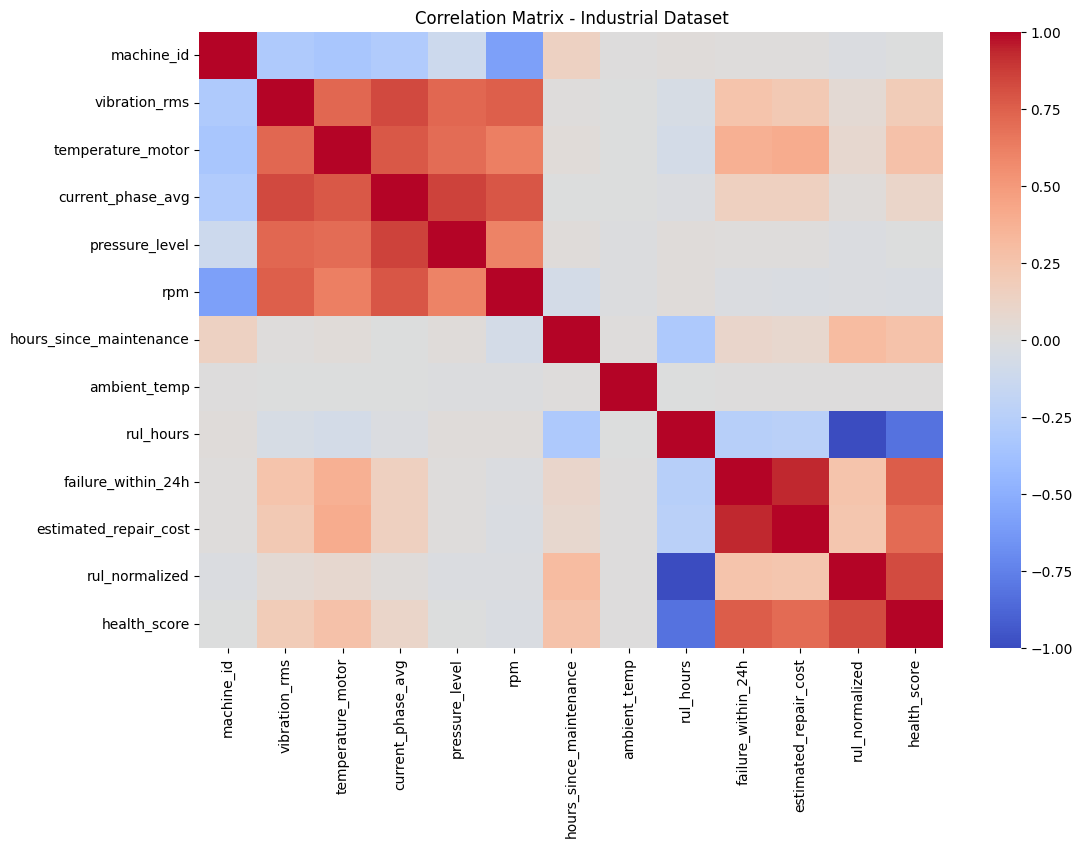

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix - Industrial Dataset")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

features = [
    "temperature_motor",
    "vibration_rms",
    "current_phase_avg",
    "pressure_level",
    "rpm",
    "hours_since_maintenance"
]

X = df[features]
y = df["failure_within_24h"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      6122
           1       0.82      0.62      0.71      1091

    accuracy                           0.92      7213
   macro avg       0.88      0.80      0.83      7213
weighted avg       0.92      0.92      0.92      7213

